In [19]:
# ESN analysis
%run -m src.ESNs.analysis.esn_analysis \
  --root "/Users/adrian/Documents/01_projects/14_4D_lab/output/02_gnm_estimation/esn_grid_resolution68_2025-08-15_09-35-26" \
  --out  "/Users/adrian/Documents/01_projects/14_4D_lab/output/analysis/esn"

# GNM analysis
# %run -m src.ESNs.analysis.gnm_analysis \
#   --grid "/.../results/gnm_grid_results_2025-08-13_18-33-59.csv" \
#   --best "/.../results/gnm_best_results_2025-08-13_18-33-59.csv" \
#   --timings "/.../preliminary_results/gnm_timing_partial_2025-08-13_18-33-59.csv" \
#   --out "/Users/adrian/Documents/01_projects/14_4D_lab/output/analysis/gnm" \
#   --title "Energy landscape, properly preprocessed connectomes"


UsageError: option --root not recognized (allowed: "nidtN:b:pD:l:rs:T:em:G")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
bin_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/connectomes_binarized_68x68_density_10_percent.npy")
weighted_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/data/preprocessed/01_first_analysises/connectomes_weighted_68x68.npy")
density_controlled_matrix = bin_matrix * weighted_matrix
print(bin_matrix.flatten()[:20])
print(weighted_matrix.flatten()[:20])
print(density_controlled_matrix.flatten()[:20])

[0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
[2.64188448e-02 3.69648683e-03 1.59035525e-03 3.89494473e-03
 2.46639916e-04 1.68966278e-05 1.16063095e-02 8.56334610e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 6.33276486e-05 2.34309988e-04 0.00000000e+00]
[0.         0.00369649 0.00159036 0.00389494 0.         0.
 0.01160631 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]


In [33]:
import bct

# Determine the density of the binarized matrix
density = bct.density_und(bin_matrix)
print(f"Density of the binarized matrix: {density}")

# Determine the density of the weighted matrix
density_weighted = bct.density_und(weighted_matrix)
print(f"Density of the weighted matrix: {density_weighted}")

# Determine the density of the density controlled matrix
density_controlled = bct.density_und(density_controlled_matrix)
# density_controlled = bct.density_dir(density_controlled_matrix)  # Use density_dir for directed matrices
print(f"Density of the density controlled matrix: {density_controlled}")


Density of the binarized matrix: (6.579710144927536, 70, 15890)
Density of the weighted matrix: (17.73374741200828, 70, 42827)
Density of the density controlled matrix: (6.579710144927536, 70, 15890)


Density of binarized matrix: 6.872837370242214
Density of weighted matrix: 0.05348641003890775
Density of density controlled matrix: 0.05025329586582688


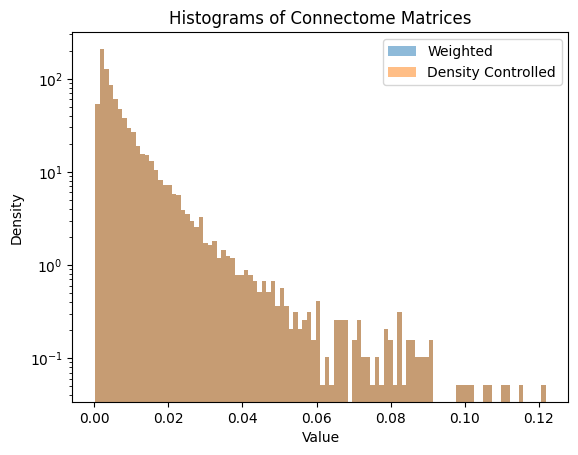

In [28]:
# plt.hist(bin_matrix.flatten(), bins=10, density=True, alpha=0.5, label='Binarized')
# remove all zero values from the histogram
# plt.hist(bin_matrix[bin_matrix > 0].flatten(), bins=100, density=True, alpha=0.5, label='Binarized') 
# plt.hist(weighted_matrix.flatten(), bins=100, density=True, alpha=0.5, label='Weighted')      
plt.hist(weighted_matrix[bin_matrix > 0].flatten(), bins=100, density=True, alpha=0.5, label='Weighted')
plt.hist(density_controlled_matrix[bin_matrix > 0].flatten(), bins=100, density=True, alpha=0.5, label='Density Controlled')
plt.yscale('log')
print("Density of binarized matrix:", np.sum(bin_matrix) / (68 * 68))
print("Density of weighted matrix:", np.sum(weighted_matrix) / (68 * 68))
print("Density of density controlled matrix:", np.sum(density_controlled_matrix) / (68 * 68))
plt.legend()
plt.title("Histograms of Connectome Matrices")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()